In [1]:
import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow import keras


I0000 00:00:1781843485.407674    6093 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781843485.478328    6093 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781843487.345907    6093 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [10]:
train_zip_data_apth = "/mnt/e/Deep Learning/data/DATA-SCIENCE-BOWL-2018/stage1_train.zip"
test_zip_data_path = "/mnt/e/Deep Learning/data/DATA-SCIENCE-BOWL-2018/stage1_test.zip"

In [ ]:
with zipfile.ZipFile(train_zip_data_apth, 'r') as f:
    f.extractall("/mnt/e/Deep Learning/data/DATA-SCIENCE-BOWL-2018/train")

In [ ]:
with zipfile.ZipFile(test_zip_data_path, 'r') as f:
    f.extractall("/mnt/e/Deep Learning/data/DATA-SCIENCE-BOWL-2018/test")

In [2]:
train_data_path = "/mnt/e/Deep Learning/data/DATA-SCIENCE-BOWL-2018/train data"
test_data_path = "/mnt/e/Deep Learning/data/DATA-SCIENCE-BOWL-2018/test data"

print(f"Number od sub in train set: {len(os.listdir(train_data_path))}")
print(f"Number of sub in test set: {len(os.listdir(test_data_path))}")

Number od sub in train set: 670
Number of sub in test set: 65


(256, 256, 3)


'/mnt/e/Deep Learning/data/DATA-SCIENCE-BOWL-2018/train data/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552/images/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png'

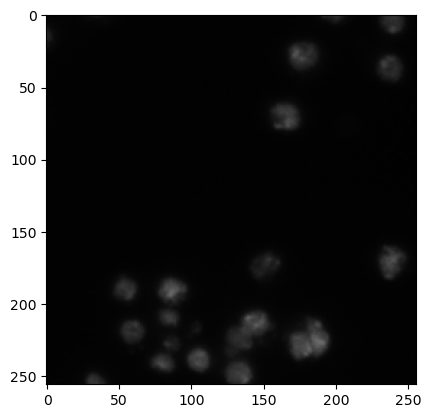

In [3]:
dir_path = "/mnt/e/Deep Learning/data/DATA-SCIENCE-BOWL-2018"

for name in os.listdir(train_data_path):
    sub_path = os.path.join(dir_path, "train data", name)
    sub_iamge_dir = os.path.join(sub_path, "images")
    
    if len(os.listdir(sub_iamge_dir)) == 1:
        sub_iamge_path = os.path.join(sub_iamge_dir, os.listdir(sub_iamge_dir)[0])
    
    break

image = cv2.imread(sub_iamge_path)
print(image.shape)
plt.imshow(image[..., ::-1])
sub_iamge_path

In [9]:
def load_dataset(path, split='train', shape=(128, 128, 3)):
    path_images = []
    path_masks = []

    for i, name in enumerate(os.listdir(path)):
        print(f"Image number: {i+1}")

        image_path = os.path.join(path, name, 'images', os.listdir(os.path.join(path, name, 'images'))[0])
        path_images.append(image_path)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (shape[1], shape[0]))

        if split == 'train':
            masks_dir = os.path.join(path, name, 'masks')

            if os.path.isdir(masks_dir):
                masks_path = os.listdir(masks_dir)
                mask = np.zeros((shape[0], shape[1]), dtype=np.uint8)

                print(f"{name} --> {len(masks_path)} masks!")

                for mask_name in masks_path:
                    mask_path = os.path.join(masks_dir, mask_name)
                    mask_image = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    mask_image = cv2.resize(
                        mask_image,
                        (shape[1], shape[0]),
                        interpolation=cv2.INTER_NEAREST
                    )
                    mask = cv2.bitwise_or(mask, mask_image)

                mask_save_path = os.path.join(masks_dir, f"{name}_mask.png")
                cv2.imwrite(mask_save_path, mask)

                path_masks.append(mask_save_path)
                print(f"Created mask for {name}.")

        print("-" * 100)

    return path_images, path_masks

In [10]:
images_train_path , masks_train_path = load_dataset(train_data_path, split='train')

Image number: 1
00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552 --> 28 masks!
Created mask for 00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.
----------------------------------------------------------------------------------------------------
Image number: 2
003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1 --> 37 masks!
Created mask for 003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1.
----------------------------------------------------------------------------------------------------
Image number: 3
00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e --> 71 masks!
Created mask for 00ae65c1c6631ae6f2be1a449902976e6eb8483bf6b0740d00530220832c6d3e.
----------------------------------------------------------------------------------------------------
Image number: 4
0121d6759c5adb290c8e828fc882f37dfaf3663ec885c663859948c154a443ed --> 87 masks!
Created mask for 0121d6759c5adb290c8e828fc882f37dfaf3663ec885c663859

In [11]:
len(images_train_path)

670

In [12]:
len(masks_train_path)

670

In [13]:
images_train_path[0]

'/mnt/e/Deep Learning/data/DATA-SCIENCE-BOWL-2018/train data/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552/images/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png'

In [14]:
images_test_path , masks_test_path = load_dataset(test_data_path, split='test')

Image number: 1
----------------------------------------------------------------------------------------------------
Image number: 2
----------------------------------------------------------------------------------------------------
Image number: 3
----------------------------------------------------------------------------------------------------
Image number: 4
----------------------------------------------------------------------------------------------------
Image number: 5
----------------------------------------------------------------------------------------------------
Image number: 6
----------------------------------------------------------------------------------------------------
Image number: 7
----------------------------------------------------------------------------------------------------
Image number: 8
----------------------------------------------------------------------------------------------------
Image number: 9
------------------------------------------------

In [15]:
len(images_test_path)

65

In [56]:
def load_image(path, image_type):
    image = tf.io.read_file(path)

    if image_type == 'image':
        image = tf.image.decode_png(image, channels=3)
    else:
        image = tf.image.decode_png(image, channels=1)

    image = tf.image.resize(image, (128, 128))

    image = tf.cast(image, tf.float32)

    if image_type == 'image':
        image = image / 255.0
    else:
        image = image / 255.0
        image = tf.where(image > 0, 1.0, 0.0)

    return image

In [57]:
train_loader = tf.data.Dataset.from_tensor_slices((images_train_path, masks_train_path))
train_loader = train_loader.map(lambda image, mask: (load_image(image, 'image'), load_image(mask, 'mask')))

val_size = 60

val_ds = train_loader.take(val_size)
train_ds = train_loader.skip(val_size)

train_loader = train_loader.shuffle(1000).batch(8).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(8).prefetch(tf.data.AUTOTUNE)

In [84]:
test_loader = tf.data.Dataset.from_tensor_slices((images_test_path))
test_loader = test_loader.map(lambda x: load_image(x, image_type='image'))

In [62]:
data = next(iter(train_loader))
image = data[0][0]
mask = data[1][0]

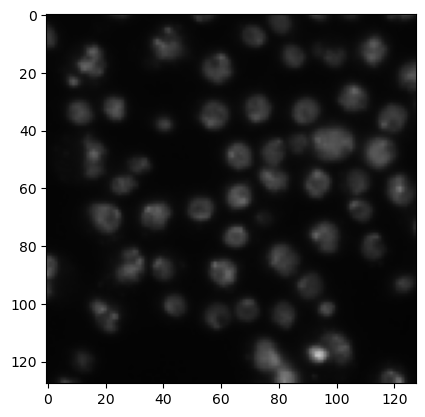

In [63]:
plt.imshow(image)

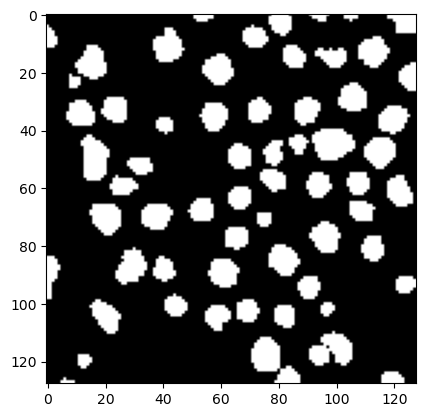

In [64]:
plt.imshow(mask, cmap='gray')

In [40]:
def dice_score(gt, pred):
    gt = tf.cast(gt, dtype=tf.float32)
    pred = tf.cast(pred, dtype=tf.float32)

    gt = tf.reshape(gt, shape=[-1])
    pred = tf.reshape(pred, shape=[-1])

    dice = (2 * tf.reduce_sum(gt * pred)) / (tf.reduce_sum(gt) + tf. reduce_sum(pred) + 0.005)

    return dice

In [41]:
dice = dice_score(mask > 1, mask > 1)

In [43]:
dice.numpy()

np.float32(0.9999983)

In [51]:
def dice_loss(gt, pred):
    return 1 - dice_score(gt, pred)

In [70]:
from keras.layers import Conv2D, Input, Conv2DTranspose, MaxPool2D, Rescaling, Dropout, concatenate
from keras.models import Model
from keras.optimizers import AdamW
from keras.losses import BinaryCrossentropy

In [79]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

input = Input(shape=(128, 128, 3))  # 128×128×3
# s = Rescaling(1. / 255)(input)      # 128×128×3

c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(input)   # 128×128×16
c1 = Dropout(0.1)(c1)                                           # 128×128×16
c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(c1)  # 128×128×16
p1 = MaxPool2D((2, 2))(c1)                                      # 64×64×16

c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)  # 64×64×32
c2 = Dropout(0.1)(c2)                                           # 64×64×32
c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(c2)  # 64×64×32
p2 = MaxPool2D((2, 2))(c2)                                      # 32×32×32

c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)  # 32×32×64
c3 = Dropout(0.1)(c3)                                           # 32×32×64
c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(c3)  # 32×32×64
p3 = MaxPool2D((2, 2))(c3)                                      # 16×16×64

c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(p3) # 16×16×128
c4 = Dropout(0.1)(c4)                                           # 16×16×128
c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(c4) # 16×16×128
p4 = MaxPool2D((2, 2))(c4)                                      # 8×8×128

c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(p4) # 8×8×256
c5 = Dropout(0.1)(c5)                                           # 8×8×256
c5 = Conv2D(256, (3, 3), activation='relu', padding='same')(c5) # 8×8×256

u6 = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(c5)  # 16×16×128
u6 = concatenate([u6, c4])                                              # 16×16×256
c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(u6)        # 16×16×128
c6 = Dropout(0.1)(c6)                                                  # 16×16×128
c6 = Conv2D(128, (3, 3), activation='relu', padding='same')(c6)        # 16×16×128

u7 = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(c6)   # 32×32×64
u7 = concatenate([u7, c3])                                             # 32×32×128
c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(u7)         # 32×32×64
c7 = Dropout(0.1)(c7)                                                  # 32×32×64
c7 = Conv2D(64, (3, 3), activation='relu', padding='same')(c7)        # 32×32×64

u8 = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same')(c7)   # 64×64×32
u8 = concatenate([u8, c2])                                             # 64×64×64
c8 = Conv2D(32, (3, 3), activation='relu', padding='same')(u8)         # 64×64×32
c8 = Dropout(0.1)(c8)                                                  # 64×64×32
c8 = Conv2D(32, (3, 3), activation='relu', padding='same')(c8)        # 64×64×32

u9 = Conv2DTranspose(16, (3, 3), strides=(2, 2), padding='same')(c8)   # 128×128×16
u9 = concatenate([u9, c1])                                             # 128×128×32
c9 = Conv2D(16, (3, 3), activation='relu', padding='same')(u9)        # 128×128×16
c9 = Dropout(0.1)(c9)                                                  # 128×128×16
c9 = Conv2D(16, (3, 3), activation='relu', padding='same')(c9)        # 128×128×16

outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)                 # 128×128×1


model = Model(inputs=input, outputs=outputs)

In [80]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_76 (Conv2D)  │ (None, 128, 128,  │        448 │ input_layer_4[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 128, 128,  │          0 │ conv2d_76[0][0]   │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_77 (Conv2D)  │ (None, 128, 128,  │      2,320 │ dropout_36[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 64, 64,    │          0 │ conv2d_77[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_78 (Conv2D)  │ (None, 64, 64,    │      4,640 │ max_pooling2d_16… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 64, 64,    │          0 │ conv2d_78[0][0]   │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_79 (Conv2D)  │ (None, 64, 64,    │      9,248 │ dropout_37[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 32, 32,    │          0 │ conv2d_79[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_80 (Conv2D)  │ (None, 32, 32,    │     18,496 │ max_pooling2d_17… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 32, 32,    │          0 │ conv2d_80[0][0]   │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, 32, 32,    │     36,928 │ dropout_38[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 16, 16,    │          0 │ conv2d_81[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, 16, 16,    │     73,856 │ max_pooling2d_18… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 16, 16,    │          0 │ conv2d_82[0][0]   │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_83 (Conv2D)  │ (None, 16, 16,    │    147,584 │ dropout_39[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_19    │ (None, 8, 8, 128) │          0 │ conv2d_83[0][0] 

 Total params: 2,158,705 (8.23 MB)

 Trainable params: 2,158,705 (8.23 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.compile(optimizer=AdamW(learning_rate=0.001), 
              loss=BinaryCrossentropy,
              metrics=[dice_score])

In [82]:
history = model.fit(train_loader, epochs=20, validation_data=val_ds)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 189ms/step - dice_score: 0.2135 - loss: 0.4452 - val_dice_score: 0.3650 - val_loss: 0.2581
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 188ms/step - dice_score: 0.6149 - loss: 0.1722 - val_dice_score: 0.7227 - val_loss: 0.1288
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 185ms/step - dice_score: 0.6986 - loss: 0.1414 - val_dice_score: 0.7075 - val_loss: 0.1311
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 187ms/step - dice_score: 0.7498 - loss: 0.1172 - val_dice_score: 0.7838 - val_loss: 0.0988
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 188ms/step - dice_score: 0.7339 - loss: 0.1256 - val_dice_score: 0.7882 - val_loss: 0.0994
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 182ms/step - dice_score: 0.7854 - loss: 0.1018 - val_dice_score: 0.7974 - val_loss: 0.0926
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 177ms/step - dice_score: 0.7985 - loss: 0.0945 - val_dice_score: 0.7990 - val_loss: 0.0939
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 178ms/step - dice_score: 0.

In [87]:
tf.data.experimental.cardinality(test_loader).numpy()

np.int64(65)

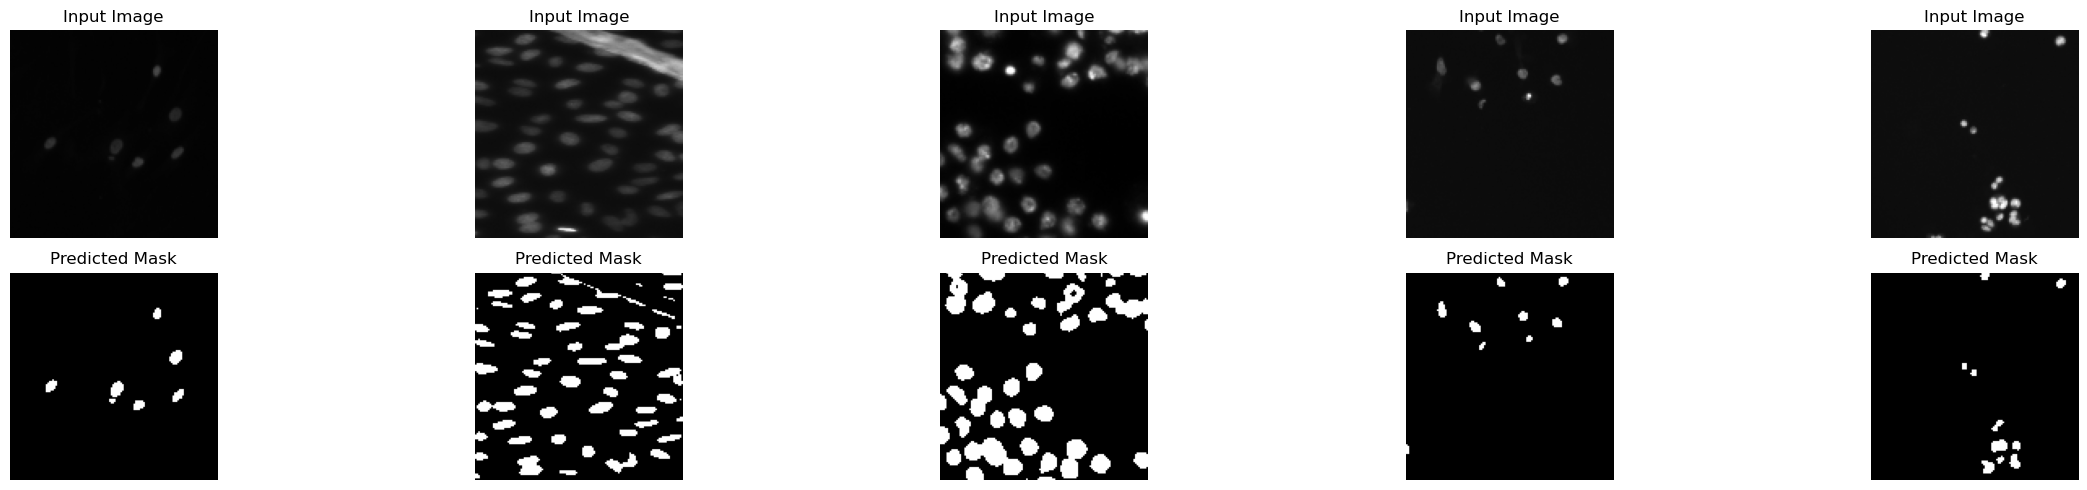

In [95]:
plt.figure(figsize=(25, 5))

for i, image in enumerate(test_loader.take(5)):
    pred = model.predict(tf.expand_dims(image, axis=0), verbose=0)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image.numpy())
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(pred[0, :, :, 0] > 0.5, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()